In [1]:
# # --- environment setup (added for the JAX backend) ---
# import os, sys
# os.environ["JAX_PLATFORMS"] = "cpu"            # this machine's METAL backend is broken
# repo_root = os.path.abspath("..")              # notebooks/ -> AnniesLasso repo root
# if repo_root not in sys.path:
#     sys.path.insert(0, repo_root)              # ensure the edited working tree is imported

import jax
jax.config.update("jax_platform_name", "cpu")

import thecannon as tc
print("thecannon:", tc.__file__)

thecannon: /scratch/mk27/mj8805/AnniesLasso/thecannon/__init__.py


In [2]:
import os
import numpy as np
import thecannon as tc
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

from thecannon import continuum

In [3]:
import pandas as pd
from pathlib import Path
SRC = Path("/home/100/mj8805/scr_mk27/")

In [4]:
spectra = pd.read_parquet(SRC / "bulge-ages-and-orbits/data/merged_with_ages_raw.parquet")

In [ ]:
original_len = len(spectra)

In [ ]:
[c for c in spectra.columns if 'RelAge' in c]

['RelAge_Dnu', 'RelAge_L']

# flags

very small 

K2 -> age based on numax have this tail??

RC has biases because we dont know mass loss

In [7]:
spectra = spectra[(spectra['flag_bad'] == 0)]
spectra = spectra[spectra['RelAge_L'] == 0]
#spectra = spectra[spectra['spectrum_flags_x'] == 0]
#spectra= spectra[spectra['snr_x'] > 100]
print(len(spectra), "/",original_len)

6893 / 23708


In [8]:
import numpy as np
import pandas as pd

STARFLAG_BITS = {
    0:  "BAD_PIXELS",
    1:  "COMMISSIONING",
    2:  "BRIGHT_NEIGHBOR",
    3:  "VERY_BRIGHT_NEIGHBOR",
    4:  "LOW_SNR",
    9:  "PERSIST_HIGH",
    10: "PERSIST_MED",
    11: "PERSIST_LOW",
    12: "PERSIST_JUMP_POS",
    13: "PERSIST_JUMP_NEG",
    16: "SUSPECT_RV_COMBINATION",
    17: "SUSPECT_BROAD_LINES",
    18: "BAD_RV_COMBINATION",
    19: "RV_REJECT",
    20: "RV_SUSPECT",
    21: "MULTIPLE_SUSPECT",
    22: "RV_FAIL",
    23: "SUSPECT_ROTATION",
    24: "MTPFLUX_LT_75",
    25: "MTPFLUX_LT_50",
}

def flag_counts(series, bit_names=STARFLAG_BITS):
    """Count how many rows have each bitmask flag set, like value_counts()."""
    vals = series.fillna(0).astype(np.int64).to_numpy()
    counts = {
        name: int(((vals >> bit) & 1).sum())
        for bit, name in bit_names.items()
    }
    return (pd.Series(counts, name="n_set")
              .sort_values(ascending=False))

counts = flag_counts(spectra['spectrum_flags_x'])
print(counts)

MTPFLUX_LT_75             855
PERSIST_LOW               673
PERSIST_HIGH              477
BRIGHT_NEIGHBOR           414
MTPFLUX_LT_50             249
PERSIST_MED               214
RV_SUSPECT                 87
SUSPECT_ROTATION           35
LOW_SNR                    27
MULTIPLE_SUSPECT           18
RV_REJECT                   5
PERSIST_JUMP_NEG            1
SUSPECT_BROAD_LINES         1
PERSIST_JUMP_POS            1
BAD_PIXELS                  0
COMMISSIONING               0
VERY_BRIGHT_NEIGHBOR        0
SUSPECT_RV_COMBINATION      0
BAD_RV_COMBINATION          0
RV_FAIL                     0
Name: n_set, dtype: int64


In [9]:
CUT_FLAGS = [
    "BAD_PIXELS",
    "COMMISSIONING",
    "BRIGHT_NEIGHBOR",
    "VERY_BRIGHT_NEIGHBOR",
    "LOW_SNR",
    "PERSIST_HIGH",
    "PERSIST_MED",
    "PERSIST_JUMP_POS",
    "PERSIST_JUMP_NEG",
    "SUSPECT_RV_COMBINATION",
    "SUSPECT_BROAD_LINES",
    "BAD_RV_COMBINATION",
    "RV_REJECT",
    "RV_SUSPECT",
    "MULTIPLE_SUSPECT",
    "RV_FAIL",
    "SUSPECT_ROTATION",
    "MTPFLUX_LT_50",
]

NAME_TO_BIT = {name: bit for bit, name in STARFLAG_BITS.items()}

cut_mask = sum(1 << NAME_TO_BIT[name] for name in CUT_FLAGS)

good = (spectra['spectrum_flags_x'].fillna(0).astype(np.int64) & cut_mask) == 0
spectra = spectra[good]

print(f"Removed {(~good).sum()} of {len(spectra)} spectra ({(~good).mean():.1%})")

Removed 1388 of 5505 spectra (20.1%)


In [17]:
spectra['mg_fe'] = spectra['raw_mg_h'] - spectra['raw_fe_h']
spectra['ca_fe'] = spectra['raw_ca_h'] - spectra['raw_fe_h']
spectra['al_fe'] = spectra['raw_al_h'] - spectra['raw_fe_h']
spectra['c_fe'] = spectra['raw_c_h'] - spectra['raw_fe_h']
spectra['n_fe'] = spectra['raw_n_h'] - spectra['raw_fe_h']
spectra['o_fe'] = spectra['raw_o_h'] - spectra['raw_fe_h']
spectra['ce_fe'] = spectra['raw_ce_h'] - spectra['raw_fe_h']
spectra['nd_fe'] = spectra['raw_nd_h'] - spectra['raw_fe_h']
spectra['log_age_Dnu'] = np.log10(spectra['age_Dnu'])

# Error on [X/Fe] = sqrt( (e_X)^2 + (e_Fe)^2 ), assuming errors are uncorrelated
spectra['e_mg_fe'] = np.sqrt(spectra['raw_e_mg_h']**2 + spectra['raw_e_fe_h']**2)
spectra['e_ca_fe'] = np.sqrt(spectra['raw_e_ca_h']**2 + spectra['raw_e_fe_h']**2)
spectra['e_al_fe'] = np.sqrt(spectra['raw_e_al_h']**2 + spectra['raw_e_fe_h']**2)
spectra['e_c_fe']  = np.sqrt(spectra['raw_e_c_h']**2  + spectra['raw_e_fe_h']**2)
spectra['e_n_fe']  = np.sqrt(spectra['raw_e_n_h']**2  + spectra['raw_e_fe_h']**2)
spectra['e_o_fe']  = np.sqrt(spectra['raw_e_o_h']**2  + spectra['raw_e_fe_h']**2)
spectra['e_ce_fe'] = np.sqrt(spectra['raw_e_ce_h']**2 + spectra['raw_e_fe_h']**2)
spectra['e_nd_fe'] = np.sqrt(spectra['raw_e_nd_h']**2 + spectra['raw_e_fe_h']**2)

# Propagate the age error to log10(age): d(log10 x) = dx / (x ln 10).
# Use half the 16th-84th percentile spread as the 1-sigma age uncertainty.
age_err = (0.5 * (spectra['age_84_L'] - spectra['age_16_L'])).clip(lower=1e-10)
age = spectra['age_L'].clip(lower=1e-10)
spectra['log_age_L'] = np.log10(age)
spectra['log_age_L_err'] = age_err / (age * np.log(10))

In [18]:
spectra['source'].value_counts()

source
K2        1620
Kepler    1230
TESS       422
Name: count, dtype: int64

In [19]:
# --- Classify stars with no seismic evolutionary state ---
# Train on the seismically labeled stars. RC and RGB only partially separate
# in Teff-logg-[Fe/H]-[C/N] label space (the label-only version of this cell
# measured ~0.83 CV accuracy here, ~0.80 in the clump box), but the spectra
# carry the CN/CH molecular features that drive the separation directly
# (Hawkins+2018, Ting+2018: ~2-3% contamination from spectra vs ~6-9% from
# labels). Use the production classifier from scripts/apply_rgb_ages.py:
# gradient boosting on the label columns plus a PCA compression of the
# continuum-normalized flux. Only high-confidence predictions
# (p > MIN_PROBA) are accepted; the rest stay unknown, so they are dropped
# by the evolutionary-state cut below rather than polluting it.
import sys
repo_root = os.path.dirname(os.path.dirname(os.path.abspath(tc.__file__)))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
from scripts.apply_rgb_ages import (classifier_matrix, _make_estimator,
                                    DEFAULT_SPECTRAL_COMPONENTS, RGB, HEB)
from scripts.train_cannon import _to_array, normalize_spectra
from sklearn.model_selection import StratifiedKFold, cross_val_predict

CLASSIFIER_FEATURES = 'both'    # 'labels', 'spectra', or 'both'
MIN_PROBA = 0.9

# The classifier consumes the same continuum normalization as the Cannon.
# This pass covers the full current sample so the unknowns can be classified;
# the training cells below re-extract and re-normalize the post-cut subset.
clf_norm_flux, clf_norm_ivar = normalize_spectra(
    _to_array(spectra['wavelength'].iloc[0]),
    np.vstack([_to_array(x) for x in spectra['flux']]),
    np.vstack([_to_array(x) for x in spectra['ivar']]),
    SRC / 'bulge-ages-and-orbits/data/continuum.list')

evo_state = pd.to_numeric(spectra['EvoState'], errors='coerce')
has_state = evo_state.isin([1, 2])
mask = has_state.to_numpy()
print(f"{has_state.sum()} stars with a seismic state, {(~has_state).sum()} without")

X = classifier_matrix(spectra.loc[has_state], clf_norm_flux[mask],
                      clf_norm_ivar[mask], CLASSIFIER_FEATURES)
y = evo_state[has_state].values
clf = _make_estimator(CLASSIFIER_FEATURES, DEFAULT_SPECTRAL_COMPONENTS)

# Honest accuracy estimates before trusting the classifier: overall, inside
# the ambiguous clump box (the only region where the answer isn't obvious
# from logg alone, so the global number is inflated by easy stars), per
# [Fe/H] quartile (domain-shift check: bulge stars skew metal-rich relative
# to the Kepler training fields), and on the confident calls only. The PCA
# sits inside the pipeline, so it is refit per CV fold -- no leakage.
proba_cv = cross_val_predict(clf, X, y, method='predict_proba',
                             cv=StratifiedKFold(5, shuffle=True, random_state=0))
classes = np.unique(y)
y_cv = classes[proba_cv.argmax(axis=1)]
acc = pd.Series(y_cv == y, index=spectra.index[has_state])
print(f"CV accuracy (all, features={CLASSIFIER_FEATURES}): {acc.mean():.3f}")

lab = spectra.loc[has_state]
in_box = ((lab['raw_logg'] > 2.2) & (lab['raw_logg'] < 2.7)
          & (lab['raw_teff'] > 4500) & (lab['raw_teff'] < 5100))
print(f"CV accuracy (clump box, n={in_box.sum()}): {acc[in_box].mean():.3f}")

feh_bin = pd.qcut(lab['raw_fe_h'], 4)
print(acc.groupby(feh_bin, observed=True).agg(['mean', 'size']))

# Boosted trees are overconfident where the features are ambiguous, so check
# the contamination among the calls the p > MIN_PROBA cut would accept.
confident_cv = proba_cv.max(axis=1) > MIN_PROBA
print(f"at p > {MIN_PROBA}: accuracy {acc[confident_cv].mean():.3f} on "
      f"{confident_cv.sum()}/{len(y)} confident CV calls "
      f"(contamination ~{1 - acc[confident_cv].mean():.1%})")

# Fit on all labeled stars and classify the unknowns.
clf.fit(X, y)
proba = clf.predict_proba(classifier_matrix(
    spectra.loc[~has_state], clf_norm_flux[~mask], clf_norm_ivar[~mask],
    CLASSIFIER_FEATURES))
pred = clf.classes_[proba.argmax(axis=1)]
confidence = proba.max(axis=1)

# Seismic state where available; high-confidence prediction otherwise. The
# evolutionary-state cut below reads EvoState_pred, so the seismic stars
# must carry their state here too -- leaving them NaN (as this cell used to)
# silently dropped every seismically labeled star from the training set.
spectra['EvoState_pred'] = evo_state.where(has_state)
spectra.loc[~has_state, 'EvoState_pred'] = np.where(
    confidence > MIN_PROBA, pred, np.nan)
n_classified = int(spectra.loc[~has_state, 'EvoState_pred'].notna().sum())
print(f"{n_classified} of {(~has_state).sum()} unlabeled stars classified with "
      f"p > {MIN_PROBA} ({(~has_state).sum() - n_classified} remain unknown)")

Normalizing:   0%|          | 0/3 [00:00<?, ?region/s]

2026-07-30 00:16:47,325 [INFO] median normalized flux on good pixels: 0.9805 (target ~1)
INFO:thecannon.train:median normalized flux on good pixels: 0.9805 (target ~1)


941 stars with a seismic state, 2331 without
CV accuracy (all, features=both): 0.867
CV accuracy (clump box, n=216): 0.778
                      mean  size
raw_fe_h                        
(-2.1, -0.293]    0.858974   234
(-0.293, -0.106]  0.858974   234
(-0.106, 0.0307]  0.900862   232
(0.0307, 0.342]   0.854701   234
at p > 0.9: accuracy 0.897 on 834/941 confident CV calls (contamination ~10.3%)
2091 of 2331 unlabeled stars classified with p > 0.9 (240 remain unknown)


In [ ]:
# --- Classifier performance summary (all from OUT-OF-FOLD predictions) ---
# Everything here reuses proba_cv from the cell above: each star's
# probability comes from a model that never saw it during training, so these
# are honest numbers to quote. RGB (EvoState=1) is the "positive" class.
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score,
                             confusion_matrix)

p_rgb = proba_cv[:, int(np.where(classes == RGB)[0][0])]
is_rgb_true = (y == RGB)
pred_cv = classes[proba_cv.argmax(axis=1)]

# What the pipeline actually accepts as RGB: p(RGB) > MIN_PROBA. Purity is
# the fraction of accepted stars that really are RGB; completeness the
# fraction of true RGB stars that make the cut.
accepted = p_rgb > MIN_PROBA
purity = float((y[accepted] == RGB).mean()) if accepted.any() else np.nan
completeness = float(accepted[is_rgb_true].mean())

summary = pd.Series({
    'seismically labeled stars': len(y),
    'RGB / RC in training': f"{int(is_rgb_true.sum())} / {int((~is_rgb_true).sum())}",
    'CV accuracy': f"{(pred_cv == y).mean():.3f}",
    'CV balanced accuracy': f"{balanced_accuracy_score(y, pred_cv):.3f}",
    'CV ROC AUC': f"{roc_auc_score(is_rgb_true, p_rgb):.3f}",
    f'RGB purity at p > {MIN_PROBA}': f"{purity:.3f}",
    f'RGB completeness at p > {MIN_PROBA}': f"{completeness:.3f}",
    f'RGB contamination at p > {MIN_PROBA}': f"{1 - purity:.1%}",
}, name='value')
print(summary.to_string())

cm = confusion_matrix(y, pred_cv, labels=classes)
print("\nconfusion matrix (rows = seismic truth, cols = CV prediction):")
print(pd.DataFrame(cm, index=['true RGB', 'true RC'],
                   columns=['pred RGB', 'pred RC']).to_string())

In [ ]:
# --- Four views of the same out-of-fold predictions, for slides ---
# (a) confusion matrix; (b) ROC with the p > MIN_PROBA operating point;
# (c) how cleanly the two classes separate in p(RGB) -- log scale, or the
#     tails near 0/1 would be invisible; (d) the purity/completeness
#     trade-off that justifies the MIN_PROBA choice.
# Same class colors as the label histograms below: coral = RGB, skyblue = RC.
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))

ax = axes[0]
im = ax.imshow(cm, cmap='Blues')
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, f"{v}\n({v / cm[i].sum():.0%})", ha='center', va='center',
            color='white' if v > cm.max() / 2 else 'black', fontsize=9)
ax.set_xticks([0, 1], ['RGB', 'RC'])
ax.set_yticks([0, 1], ['RGB', 'RC'])
ax.set_xlabel('CV prediction')
ax.set_ylabel('seismic truth')
ax.set_title('confusion matrix (argmax)')

ax = axes[1]
fpr, tpr, thr = roc_curve(is_rgb_true, p_rgb)
ax.plot(fpr, tpr, lw=1.5)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
op = np.argmin(np.abs(thr - MIN_PROBA))
ax.plot(fpr[op], tpr[op], 'o', color='crimson', label=f'p > {MIN_PROBA}')
ax.set_xlabel('false positive rate (RC accepted as RGB)')
ax.set_ylabel('true positive rate (RGB accepted)')
ax.set_title(f'ROC (AUC = {roc_auc_score(is_rgb_true, p_rgb):.3f})')
ax.legend(fontsize=8)

ax = axes[2]
bins = np.linspace(0, 1, 31)
ax.hist(p_rgb[is_rgb_true], bins=bins, alpha=0.6, color='coral',
        label='seismic RGB')
ax.hist(p_rgb[~is_rgb_true], bins=bins, alpha=0.6, color='skyblue',
        label='seismic RC')
ax.axvline(MIN_PROBA, color='k', ls='--', lw=1, label=f'accept at p > {MIN_PROBA}')
ax.set_yscale('log')
ax.set_xlabel('CV p(RGB)')
ax.set_ylabel('stars')
ax.set_title('confidence separation')
ax.legend(fontsize=8)

ax = axes[3]
ths = np.linspace(0.5, 0.99, 50)
pur = [float((y[p_rgb > t] == RGB).mean()) if (p_rgb > t).any() else np.nan
       for t in ths]
com = [float((p_rgb[is_rgb_true] > t).mean()) for t in ths]
ax.plot(ths, pur, label='purity')
ax.plot(ths, com, label='completeness')
ax.axvline(MIN_PROBA, color='k', ls='--', lw=1)
ax.set_xlabel('acceptance threshold on p(RGB)')
ax.set_ylabel('fraction')
ax.set_title('threshold trade-off')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [20]:
spectra['EvoState_pred'].value_counts()

EvoState_pred
1.0    2346
2.0     686
Name: count, dtype: int64

In [21]:
# --- Training-set quality: evolutionary state and age-label precision ---
# The C/N-age relation differs between first-ascent RGB (EvoState=1) and
# core-He-burning / red clump (EvoState=2) stars, so mixing them blurs the
# age signal. Train on one state at a time and compare.
AGE_ERR = 0.25

# Seismic state where available, high-confidence classifier prediction
# otherwise. Stars with neither fail the == comparison and are dropped.
evo = pd.to_numeric(spectra['EvoState_pred'], errors='coerce')
evo = evo.where(evo.isin([1, 2]), spectra['EvoState_pred'])
spectra = spectra[spectra['log_age_L_err'] < AGE_ERR]
spectra = spectra[
    (spectra['raw_teff']<5300) &
    (spectra['raw_logg']<3.5)
]

rgb = spectra[evo == 1]
rc = spectra[evo == 2]

print(len(rgb), 'RGB')
print(len(rc), 'RC')

2346 RGB
686 RC


In [22]:
# Most of the age information in APOGEE spectra lives in the CN molecular
# features. With [C/Fe] and [N/Fe] in the label vector alongside log(age),
# the model can attribute that signal to the abundances and starve the age
# label. Set INCLUDE_CN = False to test whether age improves without them.
INCLUDE_CN = True

LABEL_COLS = (['raw_teff', 'raw_logg', 'raw_fe_h', 'mg_fe']
              + ['c_fe', 'n_fe', 'al_fe', 'ce_fe', 'nd_fe']
              + ['o_fe', 'log_age_L'])

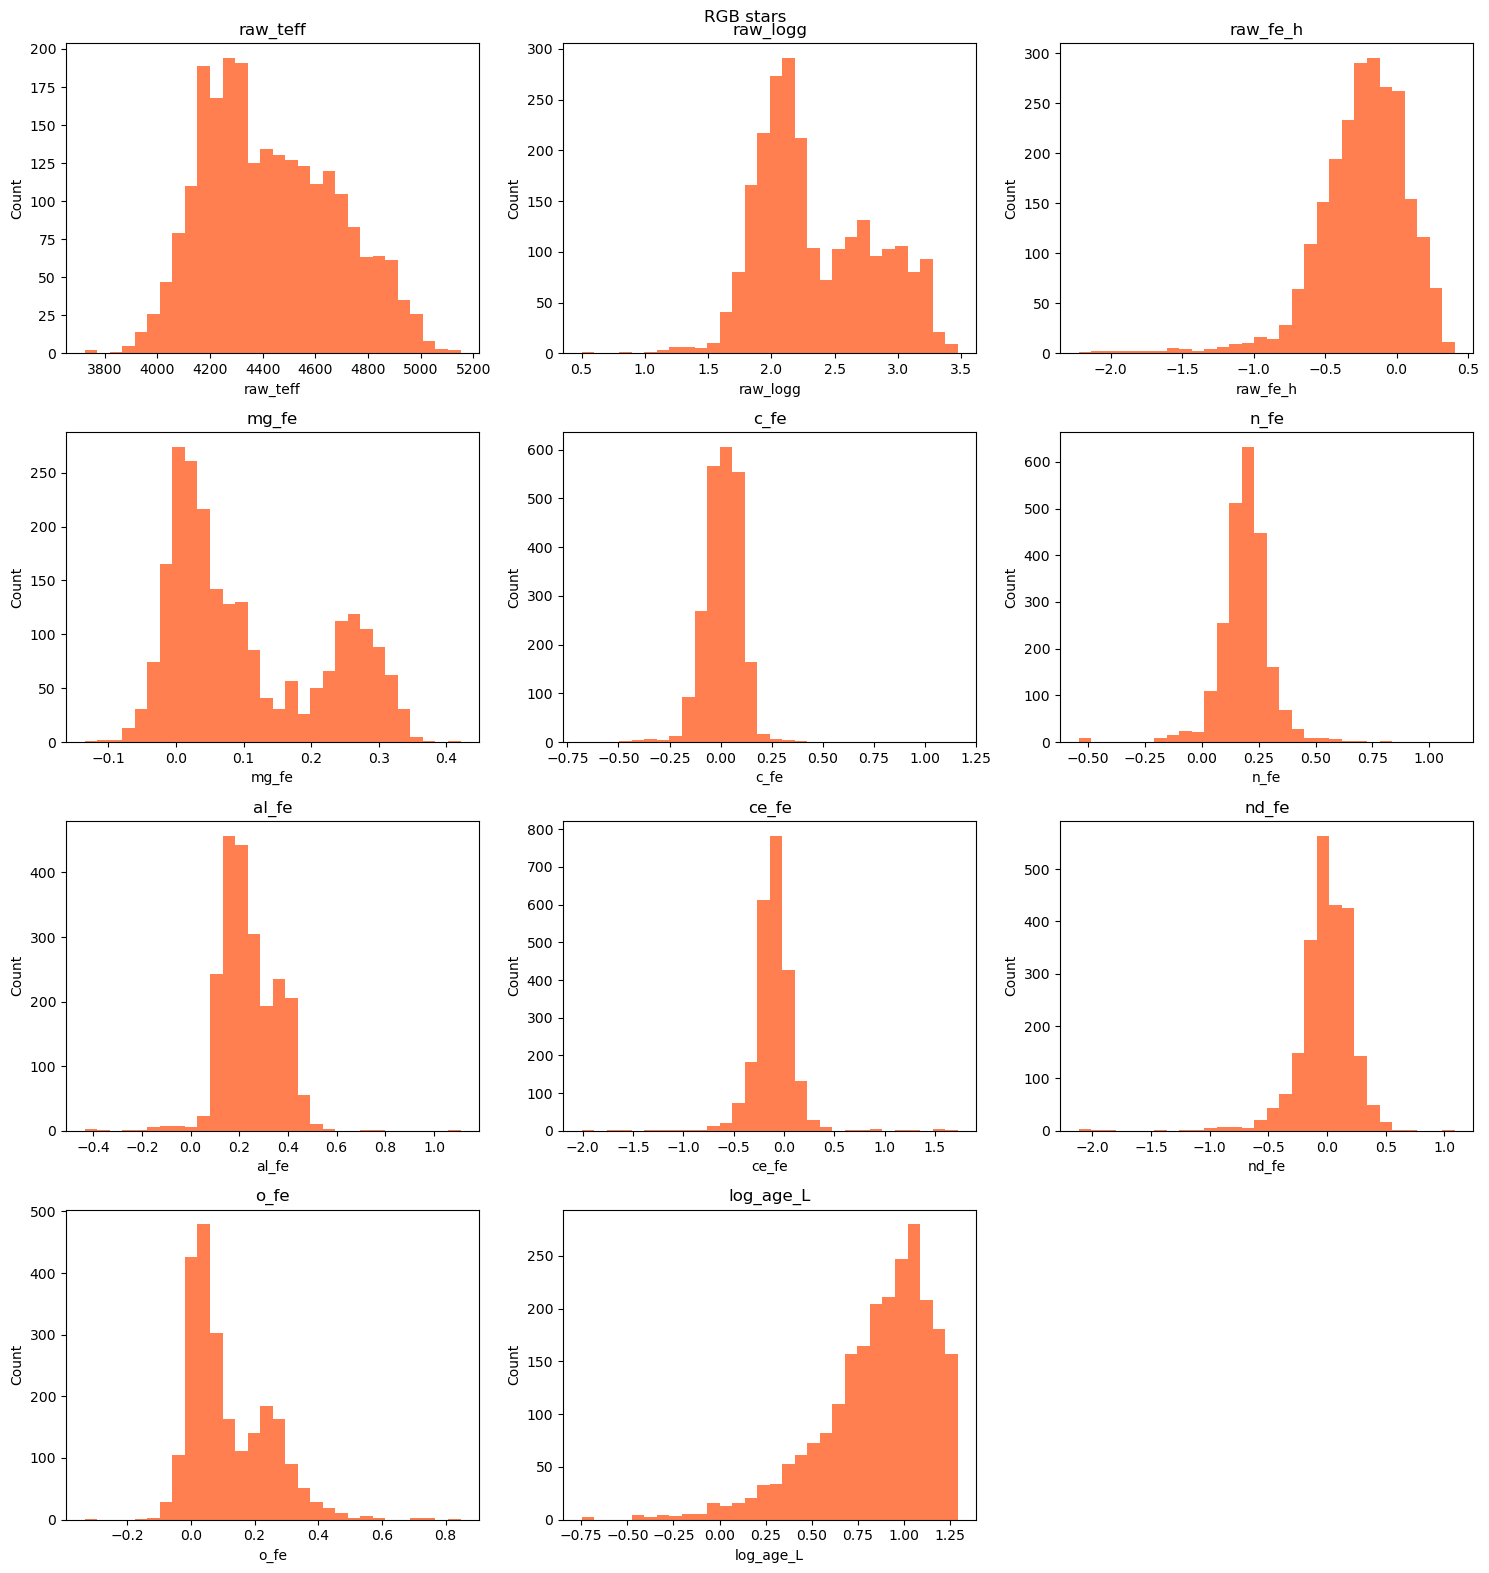

In [23]:
# Automatically plot all label columns as histograms in subplots

num_labels = len(LABEL_COLS)
ncols = 3
nrows = (num_labels + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(LABEL_COLS):
    axes[i].hist(rgb[col].dropna(), bins=30, color='coral')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('RGB stars')
plt.tight_layout()
plt.show()

KeyError: 'log_age_L'

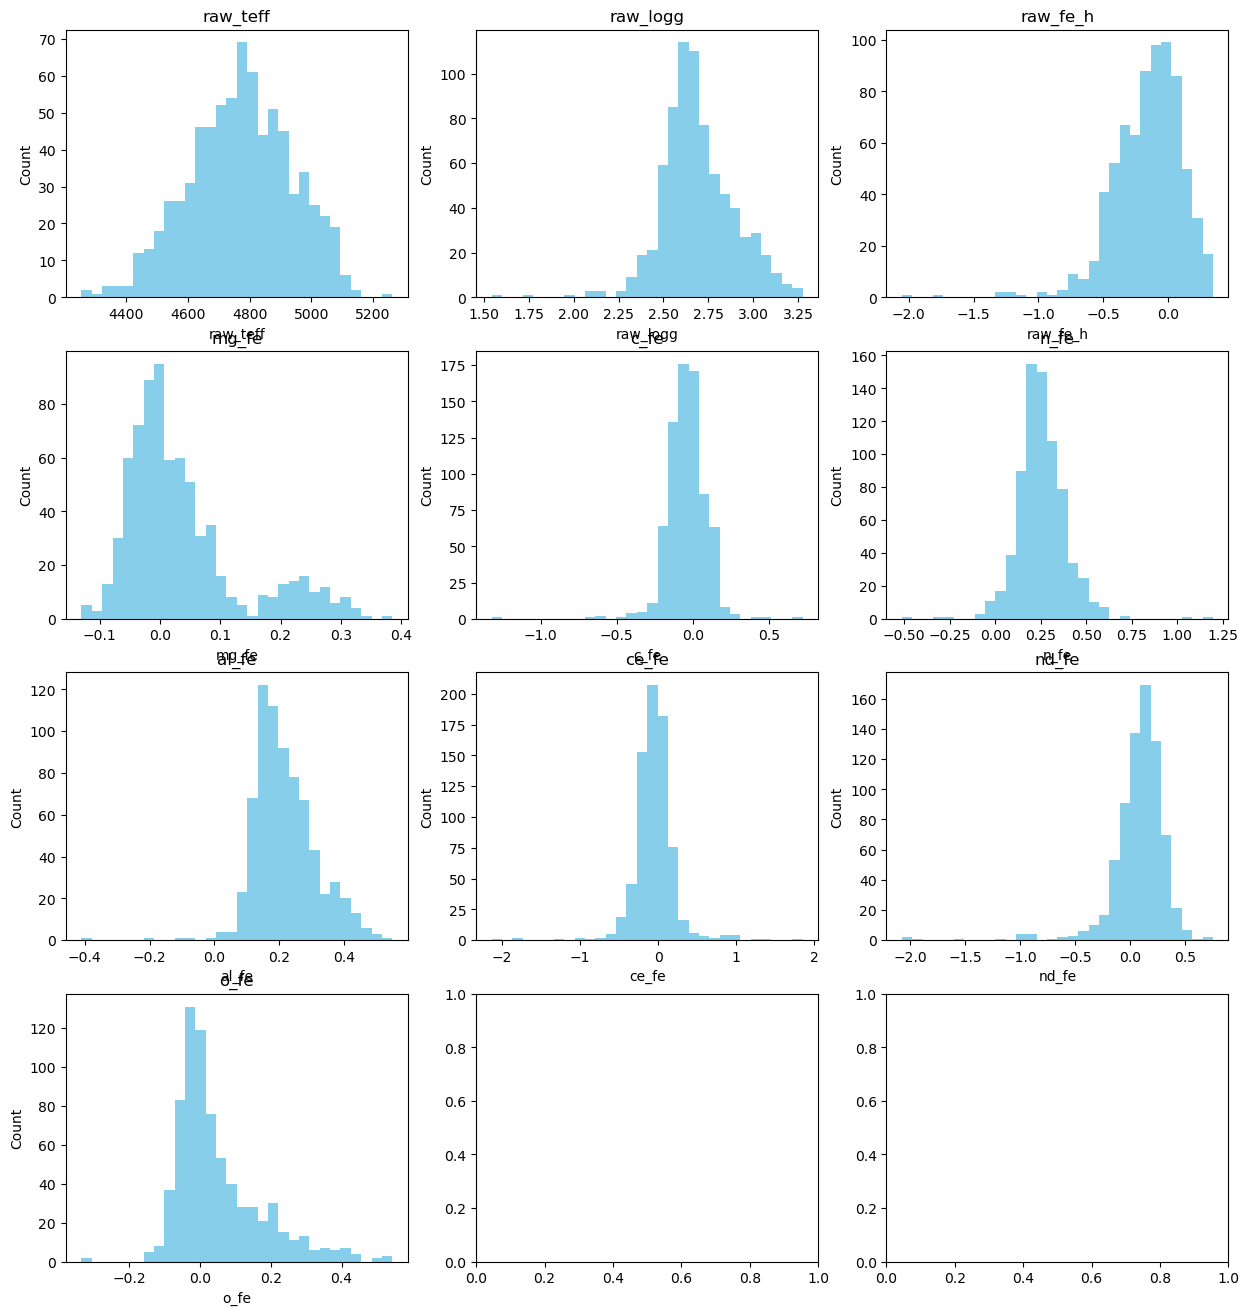

In [ ]:
# Automatically plot all label columns as histograms in subplots

num_labels = len(LABEL_COLS)
ncols = 3
nrows = (num_labels + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(LABEL_COLS):
    axes[i].hist(rc[col].dropna(), bins=30, color='skyblue')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('RC stars')
plt.tight_layout()
plt.show()

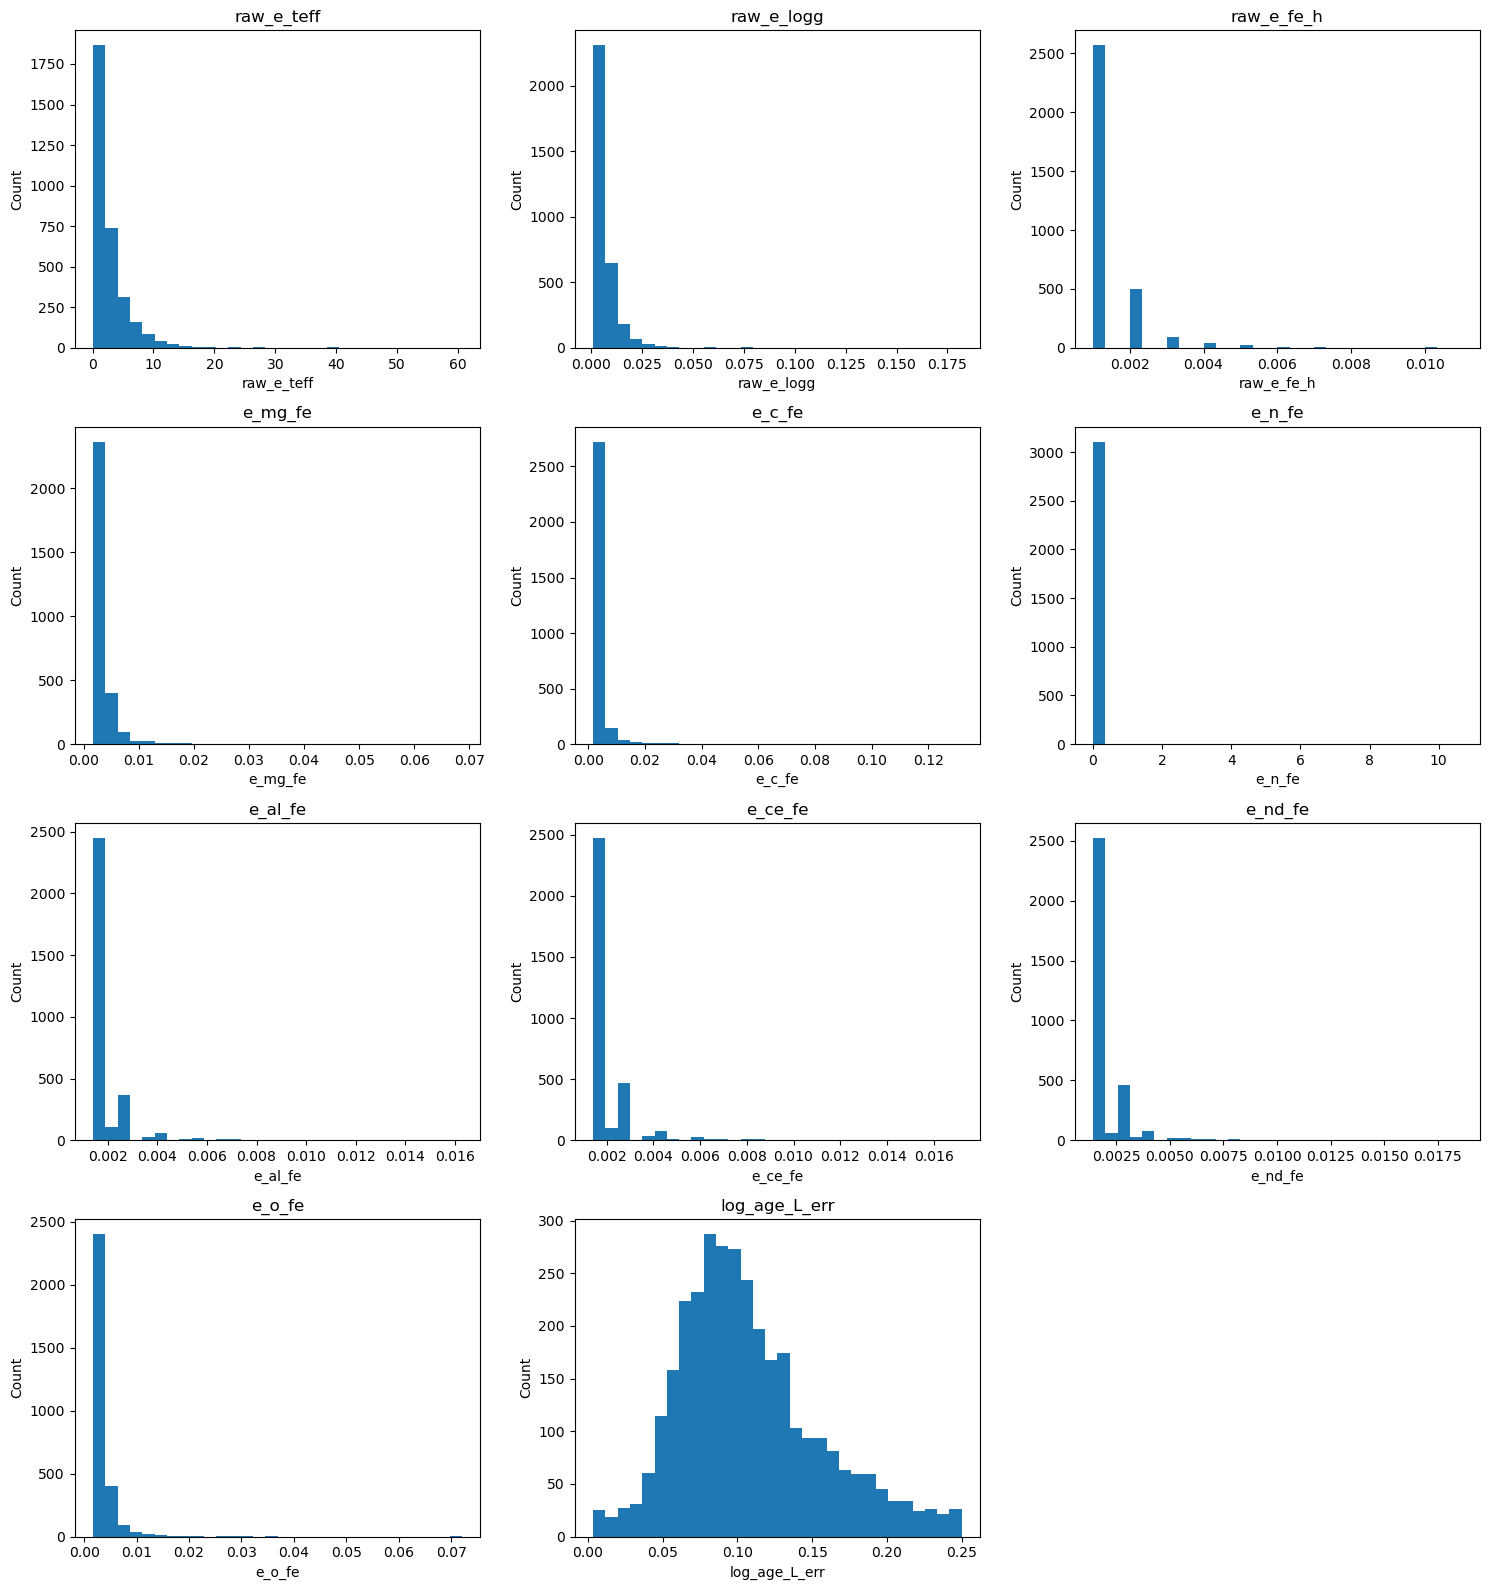

In [ ]:
# Automatically plot all label columns as histograms in subplots

num_labels = len(LABEL_COLS)
ncols = 3
nrows = (num_labels + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(LABEL_COLS):
    if col.startswith('raw_'):
        col = col.replace('raw_', 'raw_e_')
    elif col == 'log_age_L':
        col = 'log_age_L_err'
    else:
        col = 'e_' + col
    axes[i].hist(spectra[col].dropna(), bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
rgb.to_parquet('scr_mk27/rgb_clean.parquet')
rc.to_parquet('scr_mk27/rc_clean.parquet')